# Paddy Disease Detection
## Deep Learning Image Classification Project

This notebook covers the complete pipeline:
1. Data Exploration
2. Data Preprocessing
3. Data Augmentation
4. Model Building
5. Training
6. Evaluation
7. Inference

## 1. Import Libraries

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import os
import random
import pickle

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
import cv2
from PIL import Image

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input  # IMPORTANT!
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Metrics
from sklearn.metrics import classification_report, confusion_matrix

# Progress bar
from tqdm import tqdm

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU Available: []


## 2. Configuration

In [3]:
# Paths
BASE_DIR = '../data/raw'
TRAIN_DIR = os.path.join(BASE_DIR, 'train_images')
TEST_DIR = os.path.join(BASE_DIR, 'test_images')
TRAIN_CSV = os.path.join(BASE_DIR, 'train.csv')
MODEL_DIR = '../models'

# Create model directory if it doesn't exist
os.makedirs(MODEL_DIR, exist_ok=True)

# Model parameters
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 1e-3
NUM_CLASSES = 10

# Random seed for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Configuration loaded!")

Configuration loaded!


## 3. Data Exploration

In [4]:
# Load training data CSV
train_df = pd.read_csv(TRAIN_CSV)
print(f"Dataset shape: {train_df.shape}")
train_df.head(10)

Dataset shape: (10407, 4)


,image_id,label,variety,age
0,100330.jpg,bacterial_leaf_blight,ADT45,45
1,100365.jpg,bacterial_leaf_blight,ADT45,45
2,100382.jpg,bacterial_leaf_blight,ADT45,45
3,100632.jpg,bacterial_leaf_blight,ADT45,45
4,101918.jpg,bacterial_leaf_blight,ADT45,45
5,102353.jpg,bacterial_leaf_blight,ADT45,45
6,102848.jpg,bacterial_leaf_blight,ADT45,45
7,103051.jpg,bacterial_leaf_blight,ADT45,45
8,103702.jpg,bacterial_leaf_blight,ADT45,45
9,103920.jpg,bacterial_leaf_blight,ADT45,45


In [5]:
# Dataset info
print("\n=== Dataset Info ===")
print(f"Total images: {len(train_df)}")
print(f"Unique labels: {train_df['label'].nunique()}")
print(f"Unique varieties: {train_df['variety'].nunique()}")

# Class distribution
print("\n=== Class Distribution ===")
class_counts = train_df['label'].value_counts()
print(class_counts)


=== Dataset Info ===
Total images: 10407
Unique labels: 10
Unique varieties: 10

=== Class Distribution ===
label
normal                      1764
blast                       1738
hispa                       1594
dead_heart                  1442
tungro                      1088
brown_spot                   965
downy_mildew                 620
bacterial_leaf_blight        479
bacterial_leaf_streak        380
bacterial_panicle_blight     337
Name: count, dtype: int64


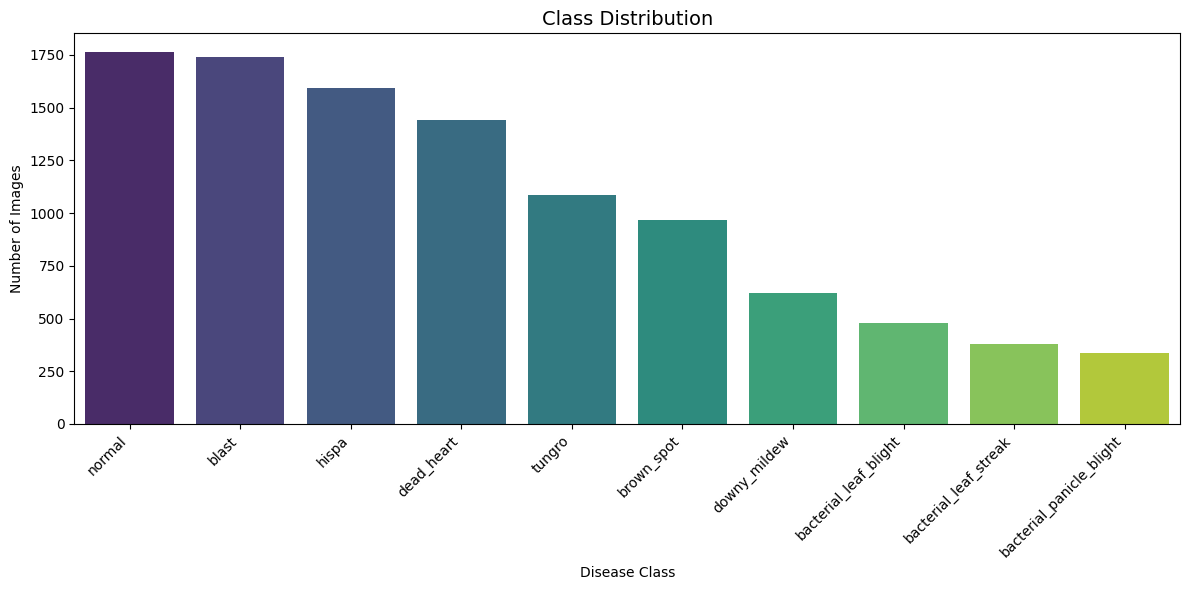

In [6]:
# Visualize class distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Class Distribution', fontsize=14)
plt.xlabel('Disease Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

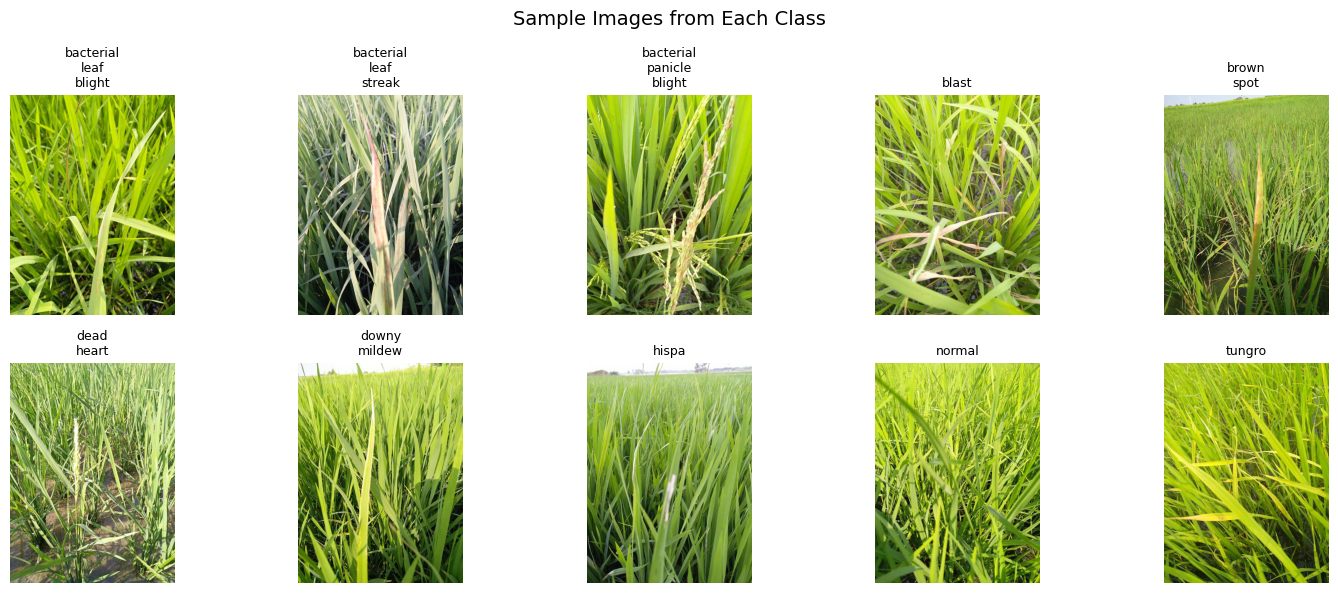

In [7]:
# Display sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, label in enumerate(train_df['label'].unique()):
    sample = train_df[train_df['label'] == label].iloc[0]
    img_path = os.path.join(TRAIN_DIR, label, sample['image_id'])
    
    if os.path.exists(img_path):
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(label.replace('_', '\n'), fontsize=9)
        axes[idx].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Augmentation


In [8]:
# Create data generators with CORRECT preprocessing for EfficientNet
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # CORRECT preprocessing for EfficientNet!
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# Validation data - only preprocessing, no augmentation
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # CORRECT preprocessing!
    validation_split=0.2
)

print("Data generators created with correct EfficientNet preprocessing!")

Data generators created with correct EfficientNet preprocessing!


In [9]:
# Create training generator
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

# Create validation generator
val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

# Print class indices
print("\nClass Indices:")
for class_name, idx in train_generator.class_indices.items():
    print(f"  {idx}: {class_name}")

# Save class indices for later use
class_indices = train_generator.class_indices
class_names = list(class_indices.keys())

# Save class names for inference
with open(os.path.join(MODEL_DIR, 'class_names.pkl'), 'wb') as f:
    pickle.dump(class_names, f)

Found 8330 images belonging to 10 classes.
Found 2077 images belonging to 10 classes.

Class Indices:
  0: bacterial_leaf_blight
  1: bacterial_leaf_streak
  2: bacterial_panicle_blight
  3: blast
  4: brown_spot
  5: dead_heart
  6: downy_mildew
  7: hispa
  8: normal
  9: tungro


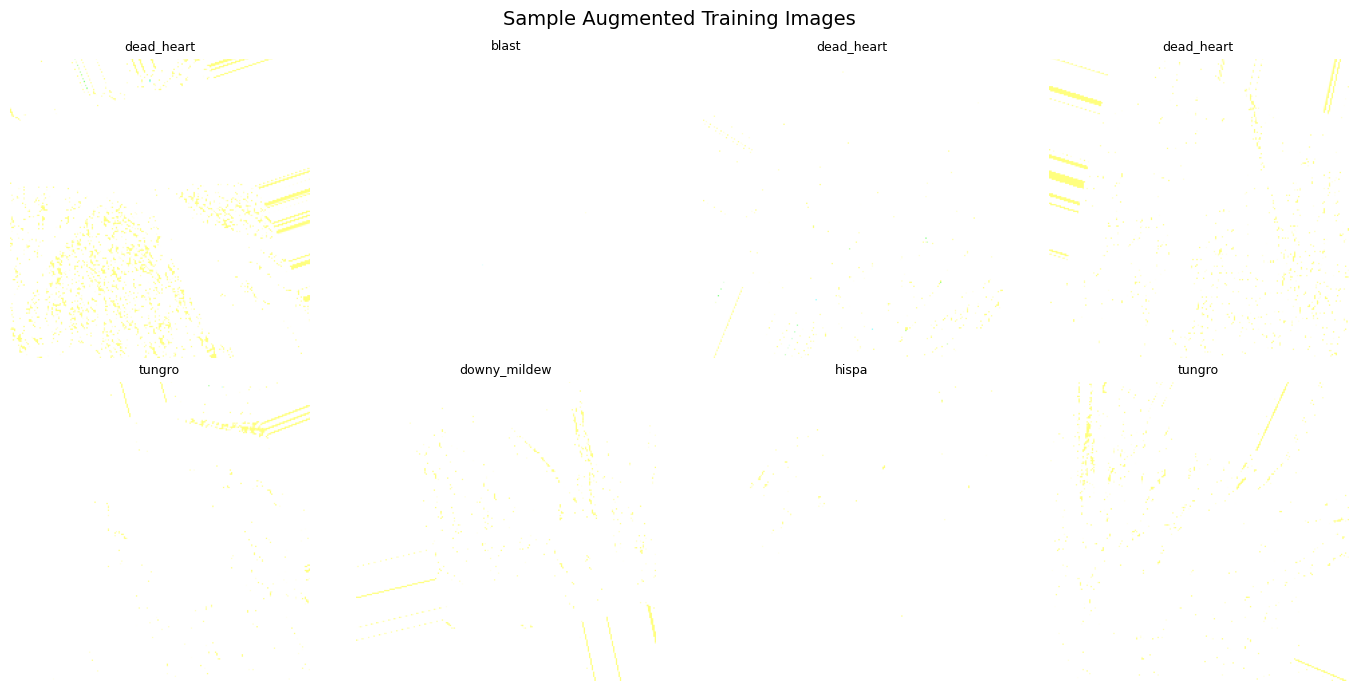

In [12]:
# Visualize some augmented images
sample_batch, sample_labels = next(train_generator)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(8):
    img = sample_batch[i].copy()
    img = (img + 1) / 2
    img = np.clip(img, 0, 1)
    
    axes[i].imshow(img)
    label_idx = np.argmax(sample_labels[i])
    axes[i].set_title(f'{class_names[label_idx]}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Augmented Training Images', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Model Building

In [11]:
def build_efficientnet_model(num_classes=10, img_size=224):
    """
    Build EfficientNetB0 model with transfer learning
    """
    # Load pre-trained EfficientNetB0
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )
    
    # Freeze base model layers initially
    base_model.trainable = False
    
    # Build model
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model, base_model

# Build model
model, base_model = build_efficientnet_model(NUM_CLASSES, IMG_SIZE)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,847,533 (18.49 MB)

 Trainable params: 793,866 (3.03 MB)

 Non-trainable params: 4,053,667 (15.46 MB)

## 6. Training

In [12]:
# Create callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'best_model.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configured!")

Callbacks configured!


In [13]:
# Train the model (Phase 1: Frozen base)
print("=" * 50)
print("PHASE 1: Training with frozen base model")
print("=" * 50)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

# Save history to avoid losing it on kernel restart
with open(os.path.join(MODEL_DIR, 'history_phase1.pkl'), 'wb') as f:
    pickle.dump(history.history, f)
print("Phase 1 history saved!")

PHASE 1: Training with frozen base model
Epoch 1/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3198 - loss: 11.8017
Epoch 1: val_accuracy improved from None to 0.50602, saving model to ../models\best_model.keras

Epoch 1: finished saving model to ../models\best_model.keras
261/261 ━━━━━━━━━━━━━━━━━━━━ 549s 2s/step - accuracy: 0.3894 - loss: 10.1951 - val_accuracy: 0.5060 - val_loss: 7.1707 - learning_rate: 0.0010
Epoch 2/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4769 - loss: 6.4575
Epoch 2: val_accuracy improved from 0.50602 to 0.56331, saving model to ../models\best_model.keras

Epoch 2: finished saving model to ../models\best_model.keras
261/261 ━━━━━━━━━━━━━━━━━━━━ 528s 2s/step - accuracy: 0.4873 - loss: 5.6671 - val_accuracy: 0.5633 - val_loss: 4.1369 - learning_rate: 0.0010
Epoch 3/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5181 - loss: 3.9824
Epoch 3: val_accuracy did not improve from 0.56331
261/261 ━━━━━━━━━━━━━━━━━━━━ 508s 2s/step - accu

In [14]:
# Fine-tuning: Unfreeze some layers and train with lower learning rate
print("\n" + "=" * 50)
print("PHASE 2: Fine-tuning (unfreezing top layers)")
print("=" * 50)

# Unfreeze the base model
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Count trainable layers
trainable_layers = sum(1 for layer in base_model.layers if layer.trainable)
print(f"Unfroze {trainable_layers} layers for fine-tuning")

# Recompile with lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE / 10),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
history_fine = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

# Save fine-tuning history
with open(os.path.join(MODEL_DIR, 'history_phase2.pkl'), 'wb') as f:
    pickle.dump(history_fine.history, f)
print("Phase 2 history saved!")


PHASE 2: Fine-tuning (unfreezing top layers)
Unfroze 30 layers for fine-tuning
Epoch 1/15
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.5532 - loss: 1.8942 
Epoch 1: val_accuracy improved from 0.73279 to 0.73712, saving model to ../models\best_model.keras

Epoch 1: finished saving model to ../models\best_model.keras
261/261 ━━━━━━━━━━━━━━━━━━━━ 2811s 11s/step - accuracy: 0.6061 - loss: 1.6985 - val_accuracy: 0.7371 - val_loss: 1.3080 - learning_rate: 1.0000e-04
Epoch 2/15
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6812 - loss: 1.4478
Epoch 2: val_accuracy improved from 0.73712 to 0.78190, saving model to ../models\best_model.keras

Epoch 2: finished saving model to ../models\best_model.keras
261/261 ━━━━━━━━━━━━━━━━━━━━ 591s 2s/step - accuracy: 0.6906 - loss: 1.4194 - val_accuracy: 0.7819 - val_loss: 1.1536 - learning_rate: 1.0000e-04
Epoch 3/15
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7308 - loss: 1.2859
Epoch 3: val_accuracy improved from 0.78190 to 

In [15]:
# Save final model
model.save(os.path.join(MODEL_DIR, 'final_model.keras'))
print(f"Model saved to {MODEL_DIR}/final_model.keras")

Model saved to ../models/final_model.keras


## 7. Training Visualization

In [19]:
# Load history if kernel was restarted
try:
    # Try to use current history
    h1 = history.history
except NameError:
    # Load from file if not in memory
    with open(os.path.join(MODEL_DIR, 'history_phase1.pkl'), 'rb') as f:
        h1 = pickle.load(f)
    print("Loaded Phase 1 history from file")

try:
    h2 = history_fine.history
except NameError:
    try:
        with open(os.path.join(MODEL_DIR, 'history_phase2.pkl'), 'rb') as f:
            h2 = pickle.load(f)
        print("Loaded Phase 2 history from file")
    except:
        h2 = None
        print("Phase 2 history not available")

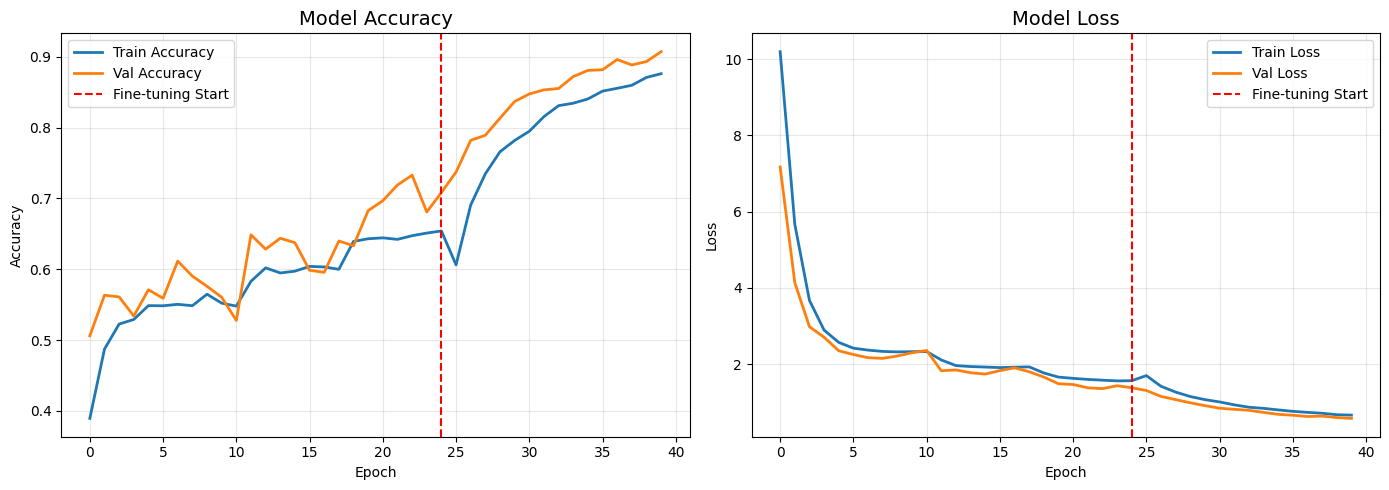


Best Validation Accuracy: 90.71% at Epoch 40


In [20]:
def plot_training_history(h1, h2=None):
    """
    Plot training history for both phases
    """
    # Combine histories if phase 2 exists
    if h2:
        combined = {
            'accuracy': h1['accuracy'] + h2['accuracy'],
            'val_accuracy': h1['val_accuracy'] + h2['val_accuracy'],
            'loss': h1['loss'] + h2['loss'],
            'val_loss': h1['val_loss'] + h2['val_loss']
        }
        phase1_epochs = len(h1['accuracy'])
    else:
        combined = h1
        phase1_epochs = None
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy plot
    axes[0].plot(combined['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0].plot(combined['val_accuracy'], label='Val Accuracy', linewidth=2)
    if phase1_epochs:
        axes[0].axvline(x=phase1_epochs-1, color='r', linestyle='--', label='Fine-tuning Start')
    axes[0].set_title('Model Accuracy', fontsize=14)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Loss plot
    axes[1].plot(combined['loss'], label='Train Loss', linewidth=2)
    axes[1].plot(combined['val_loss'], label='Val Loss', linewidth=2)
    if phase1_epochs:
        axes[1].axvline(x=phase1_epochs-1, color='r', linestyle='--', label='Fine-tuning Start')
    axes[1].set_title('Model Loss', fontsize=14)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print best results
    best_val_acc = max(combined['val_accuracy'])
    best_epoch = combined['val_accuracy'].index(best_val_acc) + 1
    print(f"\nBest Validation Accuracy: {best_val_acc*100:.2f}% at Epoch {best_epoch}")

plot_training_history(h1, h2)

## 8. Model Evaluation

In [21]:
# Load best model if needed
try:
    model
except NameError:
    model = keras.models.load_model(os.path.join(MODEL_DIR, 'best_model.keras'))
    print("Loaded model from file")

# Evaluate on validation set
val_loss, val_accuracy = model.evaluate(val_generator, verbose=1)
print(f"\nValidation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")

65/65 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9071 - loss: 0.5772

Validation Accuracy: 90.71%
Validation Loss: 0.5772


In [22]:
# Get predictions for confusion matrix
val_generator.reset()
predictions = model.predict(val_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

# Classification report
print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=class_names))

65/65 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step

CLASSIFICATION REPORT
                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.91      0.83      0.87        95
   bacterial_leaf_streak       0.94      0.96      0.95        76
bacterial_panicle_blight       0.93      0.82      0.87        67
                   blast       0.86      0.96      0.91       347
              brown_spot       0.91      0.92      0.91       193
              dead_heart       0.99      0.97      0.98       288
            downy_mildew       0.81      0.90      0.85       124
                   hispa       0.96      0.82      0.88       318
                  normal       0.89      0.92      0.91       352
                  tungro       0.88      0.88      0.88       217

                accuracy                           0.91      2077
               macro avg       0.91      0.90      0.90      2077
            weighted avg       0.91      0.91      0.91      2077



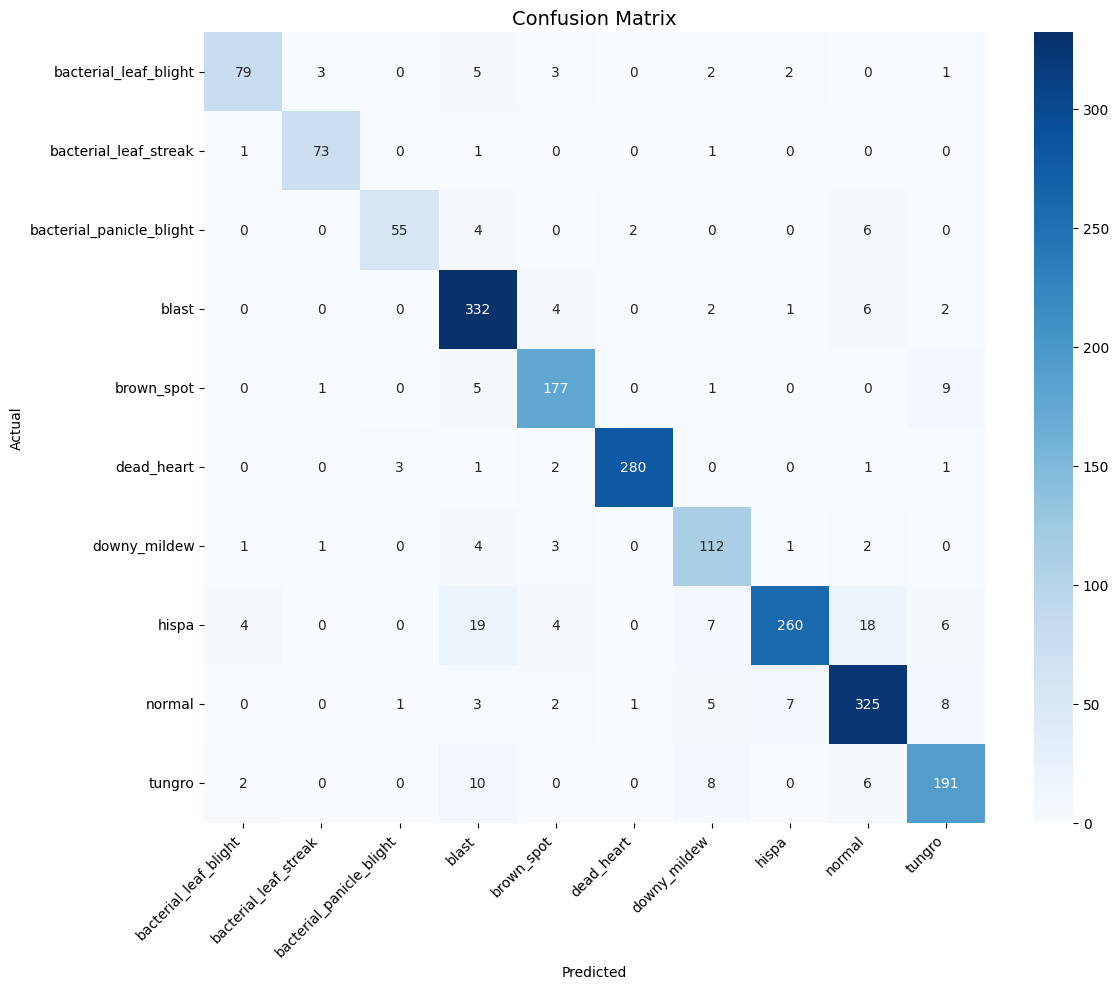

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Inference - Predict New Images

In [24]:
def predict_disease(image_path, model, class_names, img_size=224):
    """
    Predict disease from a single image
    Uses correct EfficientNet preprocessing!
    """
    # Load and preprocess image
    img = Image.open(image_path)
    img = img.resize((img_size, img_size))
    img_array = np.array(img)
    
    # Apply EfficientNet preprocessing (NOT rescale to 0-1!)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predict
    predictions = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class]
    
    return {
        'class': class_names[predicted_class],
        'confidence': confidence,
        'all_predictions': dict(zip(class_names, predictions[0]))
    }

# Example prediction
# result = predict_disease('path/to/image.jpg', model, class_names)
# print(f"Predicted: {result['class']} ({result['confidence']*100:.2f}%)")

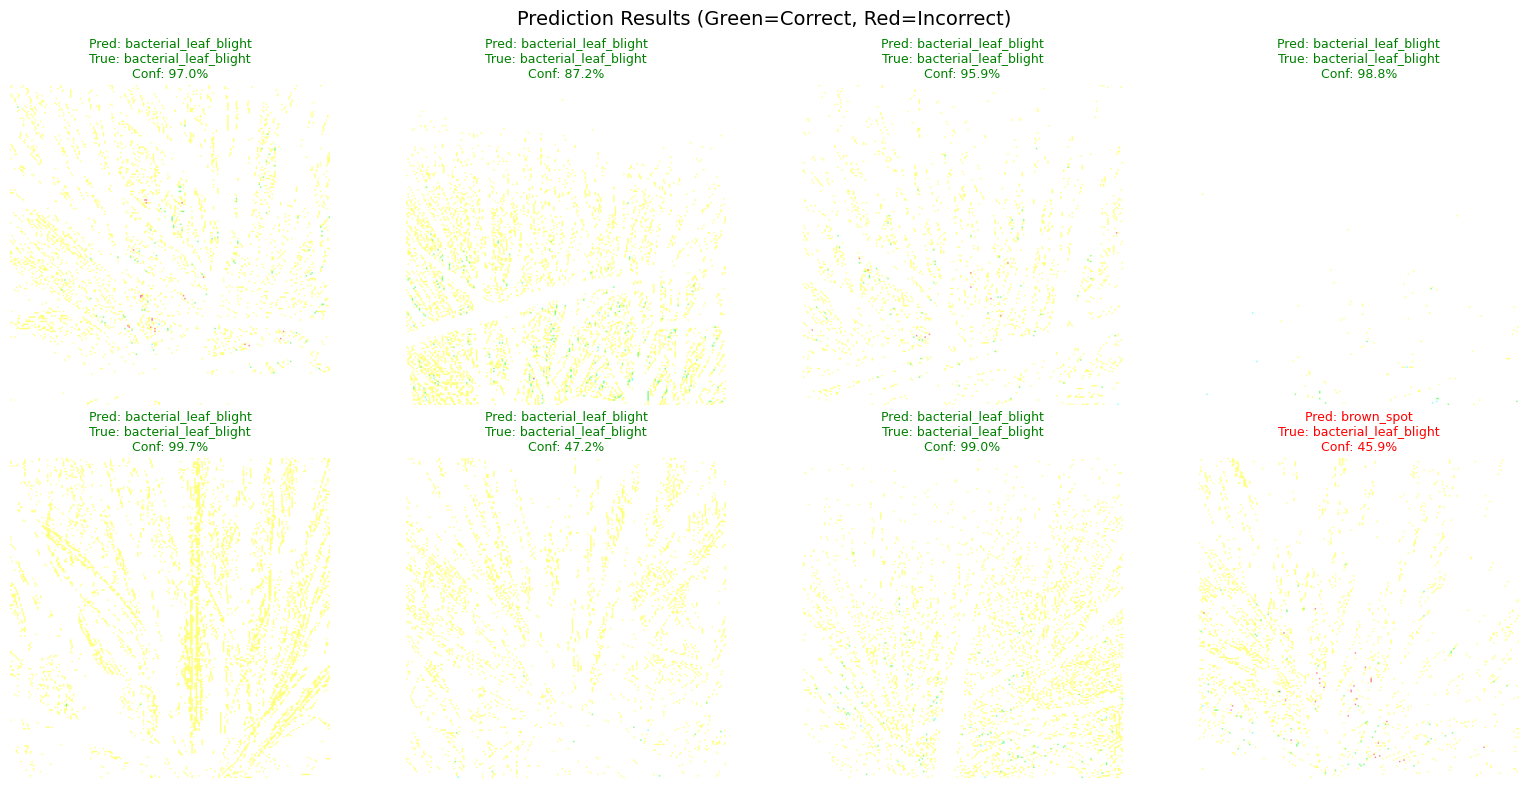

In [25]:
# Test on random validation images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Get some random validation images
val_generator.reset()
test_batch, test_labels = next(val_generator)

# Predict
test_predictions = model.predict(test_batch, verbose=0)

for i in range(8):
    pred_idx = np.argmax(test_predictions[i])
    true_idx = np.argmax(test_labels[i])
    confidence = test_predictions[i][pred_idx]
    
    # Reverse preprocessing for visualization
    img = test_batch[i].copy()
    img = (img + 1) / 2  # Convert from [-1, 1] to [0, 1]
    img = np.clip(img, 0, 1)
    
    axes[i].imshow(img)
    
    # Color based on correct/incorrect
    color = 'green' if pred_idx == true_idx else 'red'
    
    axes[i].set_title(f"Pred: {class_names[pred_idx]}\n"
                      f"True: {class_names[true_idx]}\n"
                      f"Conf: {confidence*100:.1f}%", 
                      color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Prediction Results (Green=Correct, Red=Incorrect)', fontsize=14)
plt.tight_layout()
plt.show()